# 📌 Title

# MOVIE RATING PREDICTION WITH PYTHON

## CodSoft Internship - Task 2

### Author
**Anusmita Yogamaya Nayak**

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

# Step 2 : Load Dataset

In [5]:
df = pd.read_csv("D:\CodeSoft\Task_2\IMDb Movies India.csv", encoding='latin1')

In [6]:
### Check first rows
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [8]:
# Shape
df.shape

(15509, 10)

# Step 3 : Understanding Dataset

In [9]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

# Step 4 : Data Cleaning

# Check Missing Values

In [10]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

# Remove duplicate rows

In [11]:
df.drop_duplicates(inplace=True)

# Remove unwanted spaces

In [14]:
df.columns = df.columns.str.strip()

# Step 5 : Feature Cleaning

## Year

### Current format

(2019)

In [13]:
# Convert

df['Year'] = df['Year'].str.extract('(\d+)')
df['Year'] = pd.to_numeric(df['Year'])

# Duration

### Current

109 min

In [16]:
# convert
df['Duration'] = df['Duration'].str.replace(' min','')
df['Duration'] = pd.to_numeric(df['Duration'])

# Votes

### Current

12,345

In [18]:
df['Votes'].head(20)

0      NaN
1        8
2      NaN
3       35
4      NaN
5      827
6     1086
7      NaN
8      326
9       11
10      17
11      59
12     983
13     512
14     NaN
15    6619
16     NaN
17     NaN
18     162
19     NaN
Name: Votes, dtype: object

In [19]:
df[['Votes']].sample(20)

,Votes
1825,NaN
5646,1042
9387,14
14540,20
13647,NaN
11056,25
12183,3004
4337,11
14320,13
1448,27


In [20]:
print(df.columns.tolist())

['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [21]:
df['Votes'].dtype

dtype('O')

In [23]:
# Convert
df['Votes'] = (
    df['Votes']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Step 6 : Missing Value Treatment

In [24]:
# Categorical columns

cat_cols = ['Genre','Director','Actor 1','Actor 2','Actor 3']

In [26]:
# Numeric columns

num_cols = ['Year','Duration','Votes']

In [27]:
# Target

target='Rating'

# Drop rows where Rating is missing

df=df.dropna(subset=['Rating'])

# Step 7 : Exploratory Data Analysis


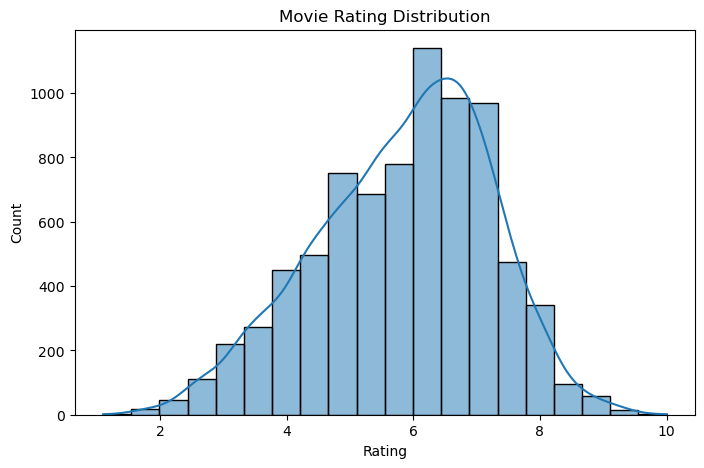

In [28]:
# Rating Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'],bins=20,kde=True)
plt.title("Movie Rating Distribution")
plt.show()

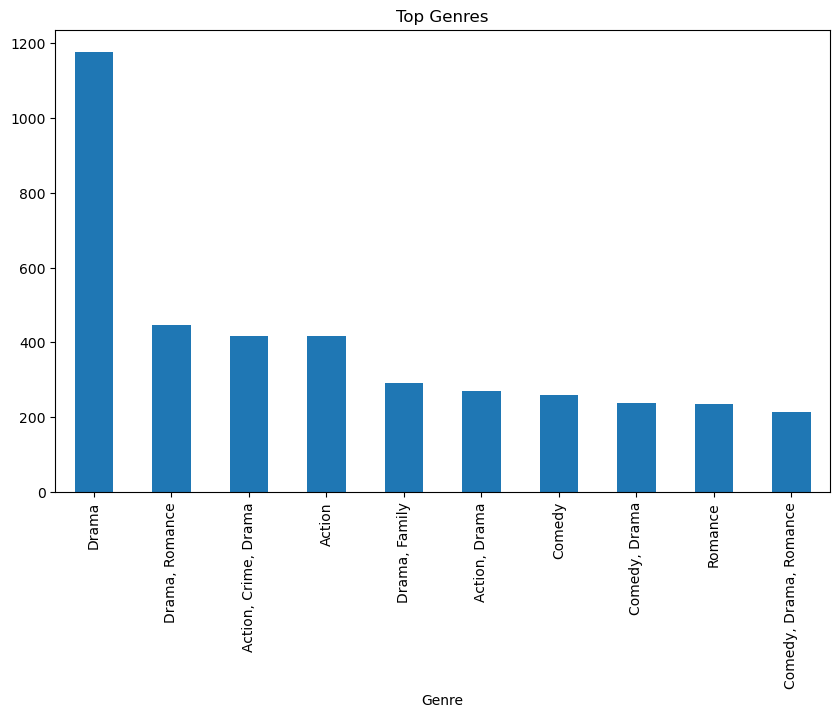

In [29]:
#Top Genres

plt.figure(figsize=(10,6))

df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")
plt.show()

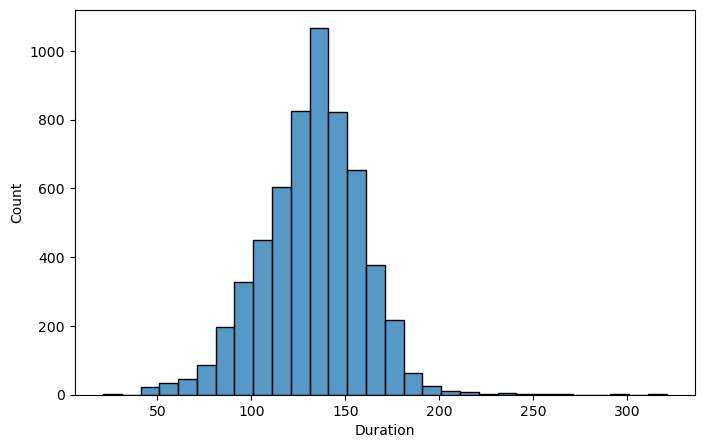

In [30]:
# Duration Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Duration'],bins=30)
plt.show()

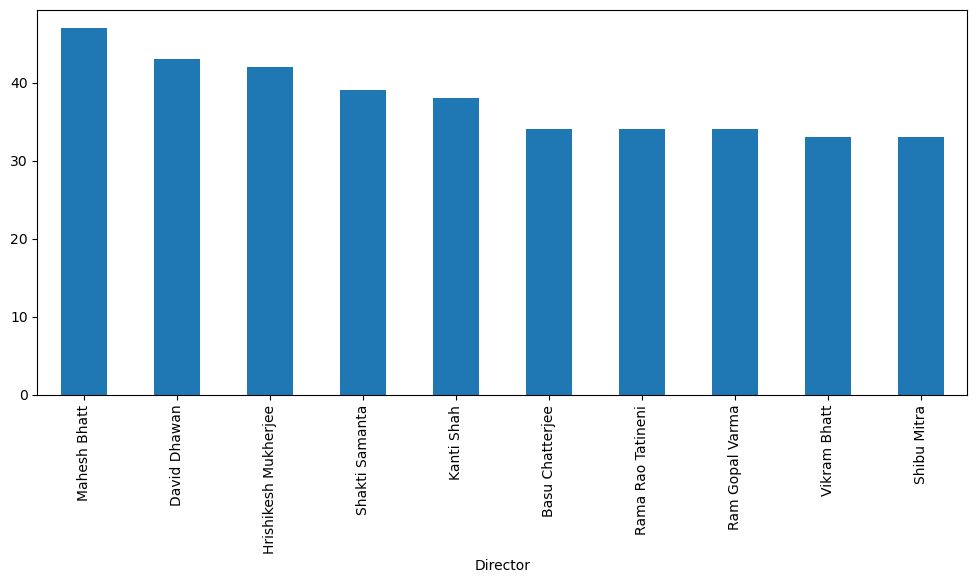

In [31]:
# Top Directors

plt.figure(figsize=(12,5))

df['Director'].value_counts().head(10).plot(kind='bar')

plt.show()

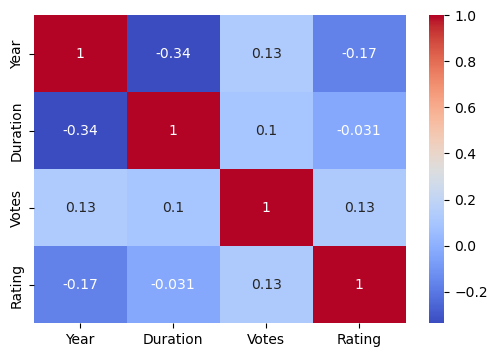

In [32]:
# Correlation

plt.figure(figsize=(6,4))

sns.heatmap(df[['Year','Duration','Votes','Rating']].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

# Step 8 : Feature Selection

In [33]:
# Input Features

X=df.drop("Rating",axis=1)

In [34]:
# Target

y=df["Rating"]

# Step 9 : Train Test Split

In [38]:

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 10 : Preprocessing Pipeline

In [39]:
# Numeric Pipeline

numeric_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="median"))

    ]
)

In [40]:
# Categorical Pipeline

categorical_transformer=Pipeline(

    steps=[

        ("imputer",SimpleImputer(strategy="most_frequent")),

        ("encoder",OneHotEncoder(handle_unknown="ignore"))

    ]
)

In [41]:
# Combine

preprocessor=ColumnTransformer(

    transformers=[

        ("num",numeric_transformer,num_cols),

        ("cat",categorical_transformer,cat_cols)

    ]
)

# Step 11 : Build Machine Learning Pipeline

In [42]:

model=Pipeline(

    steps=[

        ("preprocessor",preprocessor),

        ("regressor",RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))

    ]
)

# Step 12 : Train Model

In [43]:
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Step 13 : Prediction

In [44]:

y_pred=model.predict(X_test)

# Step 14 : Evaluation

# MAE

In [45]:
mae=mean_absolute_error(y_test,y_pred)
print(mae)

0.8009075126262624


# RMSE

In [46]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

1.0781813721172127


# R² Score

In [47]:
r2=r2_score(y_test,y_pred)
print(r2)

0.37472602554376466


# Step 15 : Actual vs Predicted

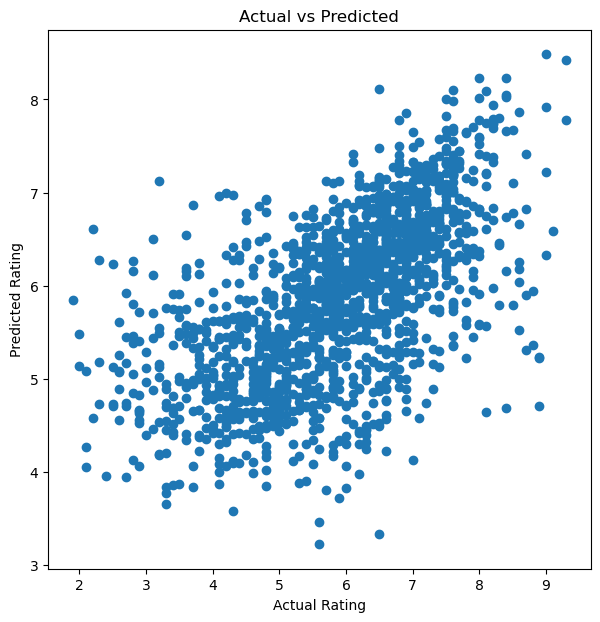

In [48]:

plt.figure(figsize=(7,7))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted")

plt.show()

# Step 16 : Save Model

In [51]:
import os
import joblib

# 1. Create the 'models' directory if it doesn't exist yet
os.makedirs("models", exist_ok=True)

# 2. Now save your model safely
joblib.dump(model, "models/movie_rating_model.pkl")

['models/movie_rating_model.pkl']

# Step 17 : Predict New Movie

In [ ]:
sample=pd.DataFrame({

'Year':[2024],

'Duration':[145],

'Votes':[25000],

'Genre':['Action'],

'Director':['S. S. Rajamouli'],

'Actor 1':['Prabhas'],

'Actor 2':['Anushka Shetty'],

'Actor 3':['Rana Daggubati']

})

prediction=model.predict(sample)

print(prediction)

# Step 18 : Feature Importance 

Random Forest provides feature importance, but because your model uses one-hot encoding in a pipeline, extracting importances requires additional code. For a first version of this project, it's acceptable to omit this section or add it later after you're comfortable with pipeline internals.

In [52]:
# Numeric feature names
numeric_features = num_cols

# Categorical feature names after One-Hot Encoding
categorical_features = model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_cols)

# Combine all feature names
feature_names = np.concatenate([numeric_features, categorical_features])

In [55]:
# Numeric feature names
numeric_features = num_cols

# Categorical feature names
categorical_features = model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(cat_cols)

# Combine feature names
feature_names = np.concatenate([numeric_features, categorical_features])

In [56]:
rf_model = model.named_steps['regressor']

importance = rf_model.feature_importances_

In [57]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head()

,Feature,Importance
2,Votes,0.200036
0,Year,0.176182
1,Duration,0.073558
239,Genre_Drama,0.022002
216,Genre_Documentary,0.017411


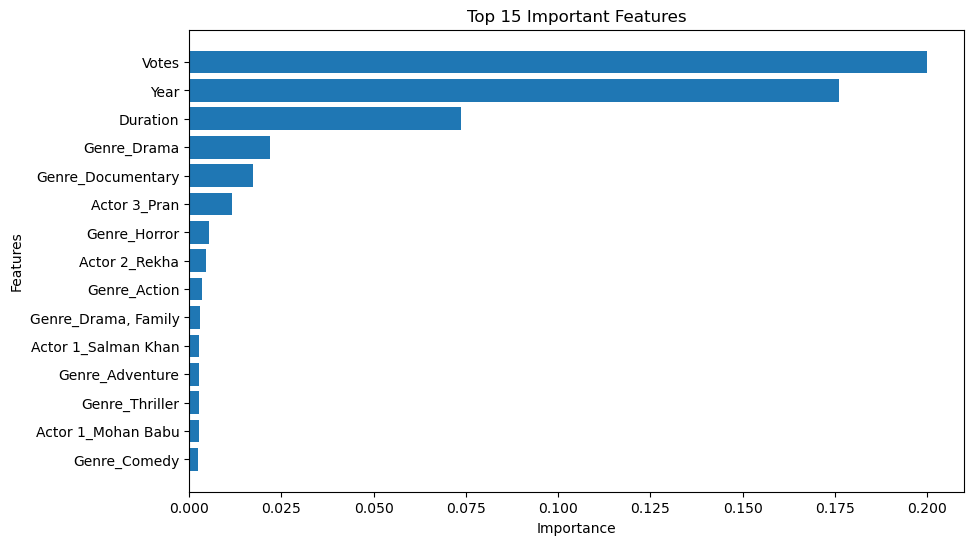

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"].head(15),
    feature_importance["Importance"].head(15)
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Important Features")

plt.show()